In [1]:
import numpy as np
import pandas as pd
import seaborn as snsn
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df_train

,id,Row#,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,450.0,12.5,0.25,0.38,0.38,0.75,86.0,52.0,71.9,62.0,30.0,50.8,1.0,0.10,0.527309,0.464892,37.021772,6620.09877
1,1,14.0,37.5,0.75,0.25,0.25,0.50,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.353236,0.383564,27.621548,3662.18313
2,2,327.0,12.5,0.25,0.25,0.75,0.75,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.510103,0.461904,37.970243,6015.22456
3,3,554.0,25.0,0.50,0.25,0.63,0.50,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.483249,0.445475,34.531142,5741.21030
4,4,685.0,25.0,0.50,0.38,0.38,0.75,94.6,57.2,79.0,68.2,33.0,55.9,16.0,0.26,0.419851,0.420094,32.849238,4813.45285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,690.0,25.0,0.50,0.38,0.38,0.75,86.0,52.0,71.9,62.0,30.0,50.8,1.0,0.10,0.502398,0.453120,36.311593,6254.82922
14996,14996,757.0,25.0,0.50,0.38,0.63,0.50,86.0,52.0,71.9,62.0,30.0,50.8,34.0,0.56,0.428322,0.408851,31.078830,4867.94772
14997,14997,109.0,12.5,0.25,0.25,0.25,0.63,69.7,42.1,58.2,50.2,24.3,41.2,34.0,0.56,0.398218,0.404576,31.665598,4016.36160
14998,14998,583.0,25.0,0.50,0.25,0.63,0.75,69.7,42.1,58.2,50.2,24.3,41.2,16.0,0.26,0.509001,0.415971,36.554327,6292.96076


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15000 non-null  int64  
 1   Row#                  15000 non-null  float64
 2   clonesize             15000 non-null  float64
 3   honeybee              15000 non-null  float64
 4   bumbles               15000 non-null  float64
 5   andrena               15000 non-null  float64
 6   osmia                 15000 non-null  float64
 7   MaxOfUpperTRange      15000 non-null  float64
 8   MinOfUpperTRange      15000 non-null  float64
 9   AverageOfUpperTRange  15000 non-null  float64
 10  MaxOfLowerTRange      15000 non-null  float64
 11  MinOfLowerTRange      15000 non-null  float64
 12  AverageOfLowerTRange  15000 non-null  float64
 13  RainingDays           15000 non-null  float64
 14  AverageRainingDays    15000 non-null  float64
 15  fruitset           

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10000 non-null  int64  
 1   Row#                  10000 non-null  float64
 2   clonesize             10000 non-null  float64
 3   honeybee              10000 non-null  float64
 4   bumbles               10000 non-null  float64
 5   andrena               10000 non-null  float64
 6   osmia                 10000 non-null  float64
 7   MaxOfUpperTRange      10000 non-null  float64
 8   MinOfUpperTRange      10000 non-null  float64
 9   AverageOfUpperTRange  10000 non-null  float64
 10  MaxOfLowerTRange      10000 non-null  float64
 11  MinOfLowerTRange      10000 non-null  float64
 12  AverageOfLowerTRange  10000 non-null  float64
 13  RainingDays           10000 non-null  float64
 14  AverageRainingDays    10000 non-null  float64
 15  fruitset            

In [7]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [9]:
X_train = df_train.drop('yield', axis=1)
y_train = df_train['yield']
X_test = df_test.copy()

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()

In [12]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
X_train.shape

(15000, 17)

In [38]:
from keras import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [79]:
model = Sequential()
model.add(Dense(units=64, activation='relu', input_shape=(17, )))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=1, activation='linear'))

C:\Users\user\Desktop\ML Python\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')

In [81]:
model.fit(X_train, y_train, validation_split=0.20, epochs=60)

Epoch 1/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3790.2153 - val_loss: 1180.3718
Epoch 2/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 984.1615 - val_loss: 781.6364
Epoch 3/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 673.2214 - val_loss: 569.2484
Epoch 4/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 492.2938 - val_loss: 428.6653
Epoch 5/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 386.5812 - val_loss: 351.8588
Epoch 6/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 337.0755 - val_loss: 318.7351
Epoch 7/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 312.0345 - val_loss: 314.6547
Epoch 8/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 301.3880 - val_loss: 302.6160
Epoch 9/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 294.1428 - val_loss: 289.1710
Epoch 10/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 290.7017 - val_loss: 292.5704
Epoch 11/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 286.5538 - val_loss: 286.5748
Epoch 

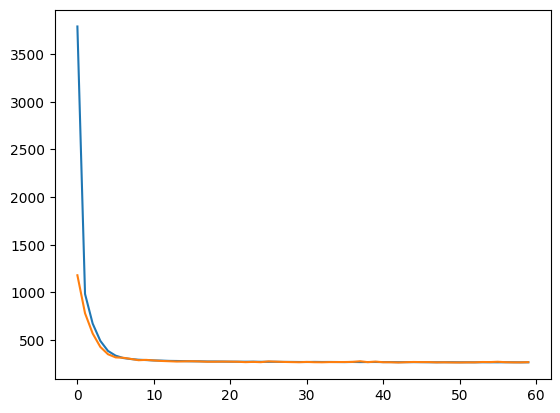

In [82]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [83]:
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [84]:
df_sub = pd.read_csv('sample_submission.csv')

In [85]:
df_sub['yield'] = y_pred

In [86]:
df_sub.to_csv('sub.csv', index=False, index_label=False)